# Student Performance Modeling: Predicting Final Mathematics Grades

## Research framing

This project investigates whether demographic, family, school, behavioral, and study-related characteristics can explain variation in students' final mathematics grades.

### Research question

> **How well can final mathematics performance be predicted from student characteristics when intermediate grades are excluded from the feature set?**

The deliberate exclusion of `G1` and `G2` is important: these are first- and second-period grades and are strongly related to the final grade `G3`. Excluding them makes the problem more difficult but focuses the analysis on student/background characteristics rather than previous assessments.

### Models

- Linear Regression — interpretable baseline
- Random Forest — nonlinear ensemble model
- Support Vector Regression — nonlinear kernel-based model

### Evaluation

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R²
- repeated cross-validation on the training set
- held-out test evaluation
- residual/prediction diagnostics
- permutation importance for the best model

The objective is not to maximize a single score, but to compare methods and understand where predictive performance comes from.


## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd().resolve()
DATA_PATH = BASE_DIR / "data" / "student-mat.csv"

# Make the notebook robust when launched from notebooks/
if not DATA_PATH.exists():
    DATA_PATH = BASE_DIR.parent / "data" / "student-mat.csv"

RESULTS_DIR = BASE_DIR / "results" / "figures"
if not RESULTS_DIR.exists():
    RESULTS_DIR = BASE_DIR.parent / "results" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Results directory:", RESULTS_DIR)


Data path: /mnt/data/student_performance_prediction_research/data/student-mat.csv
Results directory: /mnt/data/student_performance_prediction_research/results/figures


## 2. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")

print("Shape:", df.shape)
display(df.head())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget summary:")
display(df["G3"].describe())


Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10



Missing values:


school     0
sex        0
age        0
address    0
famsize    0
Pstatus    0
Medu       0
Fedu       0
Mjob       0
Fjob       0
dtype: int64


Duplicate rows: 0

Target summary:


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

## 3. Exploratory analysis

The final grade `G3` ranges from 0 to 20. We first inspect its distribution and selected relationships before modeling.


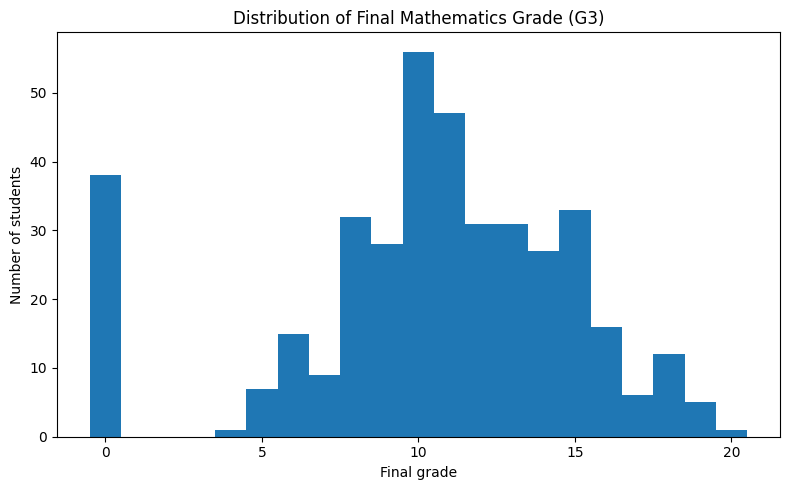

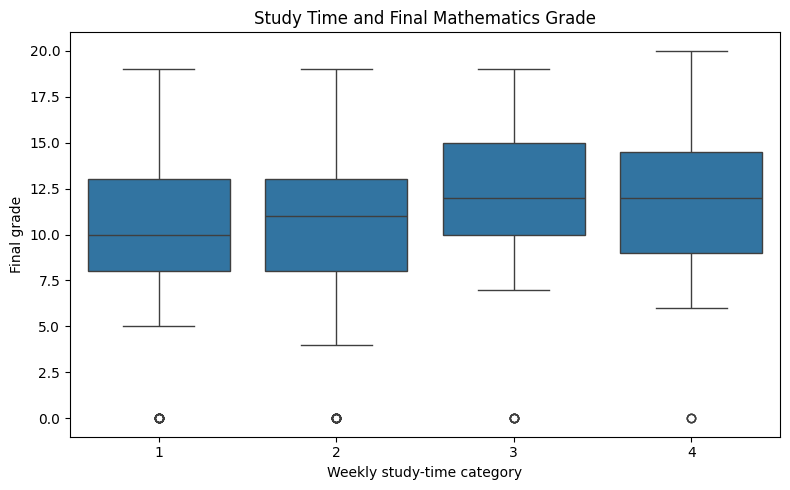

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["G3"], bins=np.arange(-0.5, 21.5, 1))
ax.set_title("Distribution of Final Mathematics Grade (G3)")
ax.set_xlabel("Final grade")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "grade_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="studytime", y="G3", ax=ax)
ax.set_title("Study Time and Final Mathematics Grade")
ax.set_xlabel("Weekly study-time category")
ax.set_ylabel("Final grade")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "studytime_vs_grade.png", dpi=200, bbox_inches="tight")
plt.show()


### Correlation analysis

The numerical variables are examined using Spearman correlation because many behavioral and ordinal variables are not naturally continuous.


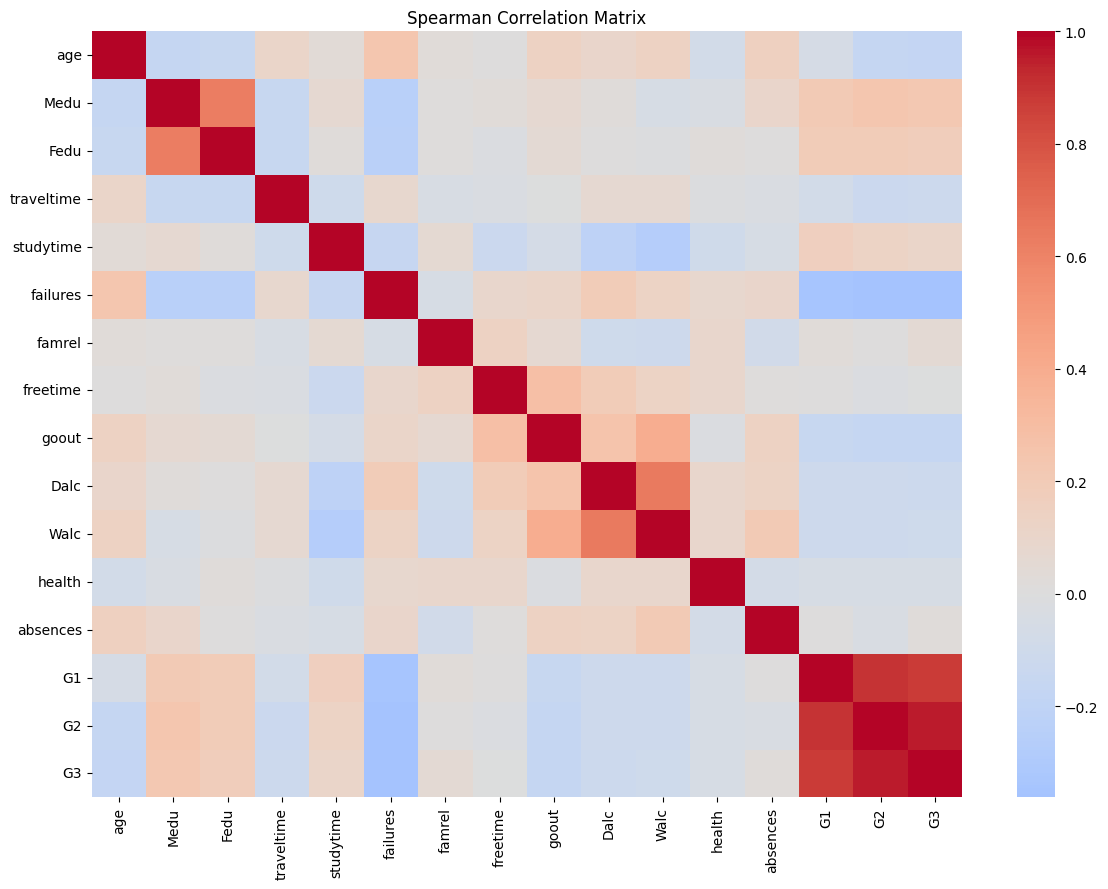

,Spearman correlation with G3
G2,0.957125
G1,0.878001
failures,-0.361224
Medu,0.225036
age,-0.173438
Fedu,0.170049
goout,-0.166119
Dalc,-0.120944
traveltime,-0.120530
studytime,0.105170


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "spearman_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    corr["G3"]
    .drop("G3")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Spearman correlation with G3")
)


## 4. Feature design

`G1` and `G2` are deliberately excluded.

According to the UCI dataset documentation, `G1` and `G2` are first- and second-period grades and have a strong correlation with `G3`. Including them would produce a much easier prediction task and would not answer the intended research question of predicting performance from student characteristics.

The target is therefore:

- **Target:** `G3`
- **Excluded:** `G1`, `G2`
- **Predictors:** demographic, family, school, behavioral, and study-related variables


In [5]:
TARGET = "G3"
EXCLUDED = ["G1", "G2"]

X = df.drop(columns=[TARGET] + EXCLUDED)
y = df[TARGET]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of predictors:", X.shape[1])
print("Categorical predictors:", len(categorical_features))
print("Numerical predictors:", len(numeric_features))


Number of predictors: 30
Categorical predictors: 17
Numerical predictors: 13


## 5. Train/test split and preprocessing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 316
Testing observations: 79


## 6. Model comparison

Three models are evaluated using the same preprocessing pipeline.

Cross-validation is performed **only on the training data**. The test set is kept untouched until final evaluation.


In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVR": SVR(C=10, epsilon=0.2, kernel="rbf")
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_RMSE")
display(cv_results_df.round(3))


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


,Model,CV_MAE,CV_RMSE,CV_R2
1,Random Forest,2.959,3.936,0.208
2,SVR,3.190,4.277,0.080
0,Linear Regression,3.523,4.607,-0.092


## 7. Held-out test evaluation

In [8]:
test_results = []
test_predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    test_predictions[name] = pred

    test_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

test_results_df = pd.DataFrame(test_results).sort_values("RMSE")
display(test_results_df.round(3))


,Model,MAE,RMSE,R2
1,Random Forest,3.064,3.832,0.284
2,SVR,3.376,4.103,0.179
0,Linear Regression,3.395,4.196,0.141


## 8. Prediction diagnostics

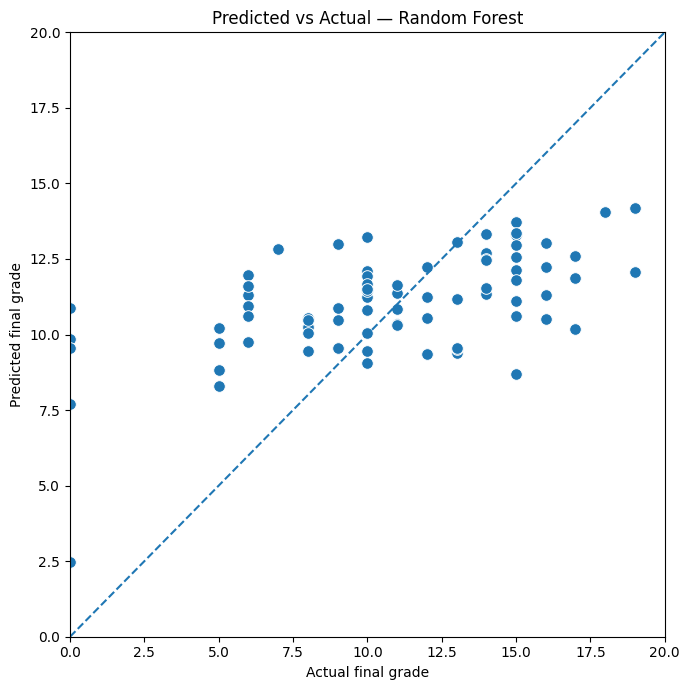

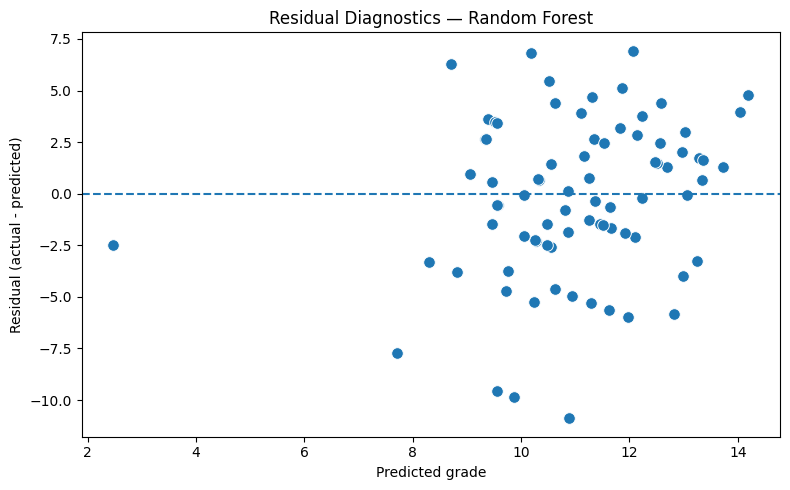

In [9]:
best_model_name = test_results_df.iloc[0]["Model"]
best_pred = test_predictions[best_model_name]

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=best_pred, s=70)
plt.plot([0, 20], [0, 20], linestyle="--")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.xlabel("Actual final grade")
plt.ylabel("Predicted final grade")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_model_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_pred, y=residuals, s=70)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted grade")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residual Diagnostics — {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_model_residuals.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Permutation importance

Permutation importance is calculated on the held-out test set for the best model.

This asks:

> How much does predictive performance deteriorate when one feature is randomly shuffled?

Unlike raw tree impurity importance, permutation importance can be evaluated on unseen data and is easier to interpret as a predictive diagnostic.


,Mean permutation importance
failures,0.615939
absences,0.439136
goout,0.131496
sex,0.109315
Medu,0.069087
schoolsup,0.059238
age,0.049373
guardian,0.043608
reason,0.034474
studytime,0.018416


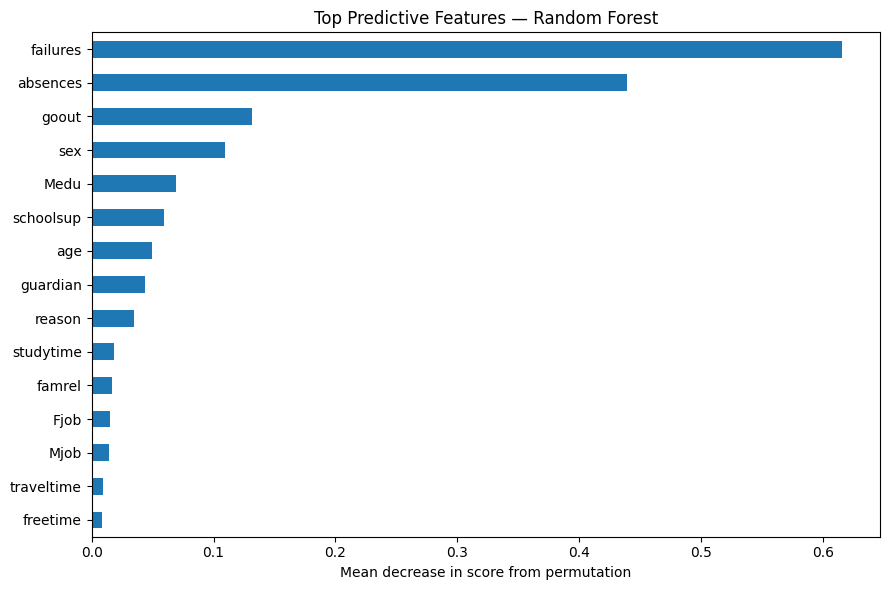

In [10]:
best_pipeline = pipelines[best_model_name]

perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

display(importance.head(15).to_frame("Mean permutation importance"))

plt.figure(figsize=(9, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Mean decrease in score from permutation")
plt.title(f"Top Predictive Features — {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. Interpretation and limitations

### Interpretation

The models estimate predictive associations between student characteristics and final mathematics grades. They do **not** establish that any observed variable causes changes in academic performance.

The comparison between cross-validation and held-out test performance is especially important because the dataset is relatively small. A single train/test split can produce unstable estimates.

### Important limitations

1. The dataset contains 395 mathematics students, so uncertainty around performance estimates should be considered.
2. The observations come from two Portuguese secondary schools and may not generalize to other populations.
3. The target is a final grade and is influenced by many unmeasured factors.
4. `G1` and `G2` are excluded intentionally; including them would answer a different and easier prediction problem.
5. Predictive feature importance should not be interpreted as causal importance.
6. The dataset is observational, so causal claims are outside the scope of this analysis.

### Future work

- repeated nested cross-validation
- uncertainty intervals for model performance
- calibrated classification of risk groups
- SHAP-based explanations
- fairness/error analysis across demographic groups
- external validation on an independent school or cohort
- comparison with the Portuguese-language dataset


## 11. Reproducibility

The project uses a fixed random seed, explicit preprocessing pipelines, 5-fold cross-validation, and a held-out test set.

Run:

```bash
pip install -r requirements.txt
```

Then execute the notebook from the repository root.
